# 6. The density of states: smearing and tetrahedra

Everything so far has produced *eigenvalues*: a number per band per k-point. The density of
states is the first quantity that is not one of those but an integral over all of them,

    D(E) = sum_n integral_BZ delta(E - e_n(k)) dk / (2 pi)^3,

and it is where the k-point sum stops being a technicality and becomes the whole
calculation. A delta function cannot be summed on a finite grid, so it has to be replaced
by something, and the two ways of doing that are what this notebook is about:

1. **Smearing** replaces the delta by a normalised bump of width `degauss` and sums over
   the k-points. It works on any k-set and always gives something smooth --- including
   inside a band gap, where the answer is zero.
2. **Tetrahedra** interpolate the bands linearly inside the tetrahedra the k-grid is cut
   into, and integrate the delta exactly. There is no width, so a gap really is empty ---
   but it needs the uniform grid the k-points came from.

Along the way, three things that are more about *how this code is written* than about
densities of state:

* only the **integrated** DOS is ever written down, and `D(E)` is `jax.grad` of it;
* the smeared delta is `jax.jvp` of the occupation function the SCF already used, so the
  two cannot drift apart;
* every branch of Quantum ESPRESSO's `IF/ELSEIF` chain is evaluated and then selected,
  which introduces a NaN-in-gradient trap that QE never meets.

The reference for all of it is `PW/src/tetra.f90`, `PP/src/dos.f90` and `PP/src/dosg.f90`.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from pypresso.io import read_qe_output, format_dos
from pypresso.io.pwin import read_pw_input
from pypresso.pseudo import read_upf
from pypresso.scf import run_scf
from pypresso.scf.occupations import wgauss, w0gauss
from pypresso.system import build_system
from pypresso.units import RY_TO_EV
from pypresso.workflows import run_dos, run_nscf, denser_grid

QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite")
PSEUDO = Path("../tests/data/pseudo")


def load(path):
    system = build_system(read_pw_input(path))
    pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
    return system, pseudos


si, si_pseudos = load(QE / "pw_scf" / "scf.in")
si_scf = run_scf(si, si_pseudos, conv_thr=1e-10)
print(f"silicon: {si.kpoints.nk} k-points in the SCF, E = {si_scf.total_energy:.8f} Ry")
print(f"         HOMO = {si_scf.homo * RY_TO_EV:.4f} eV")

silicon: 2 k-points in the SCF, E = -15.79449557 Ry
         HOMO = 5.5365 eV


## 1. A density of states is a non-self-consistent run

The SCF above used **two** k-points. That is enough for the density --- silicon's total
energy is converged to 1e-9 Ry with it --- and nowhere near enough for a density of
states, which needs to resolve structure a few tens of meV wide. So a DOS is a three-step
calculation, and `run_dos` is exactly those three steps:

    SCF on the input's grid  ->  NSCF on a denser one, density frozen  ->  integrate

The middle step is `workflows/nscf.py`, the same fixed-density diagonalisation a band
structure uses; the only difference is that a DOS wants a uniform grid where a band
structure wants a path.

In [2]:
grid = (12, 12, 12)
nscf = run_nscf(si, si_pseudos, si_scf.density, kpoints=denser_grid(si, grid), nbnd=8)
print(f"{grid[0]}x{grid[1]}x{grid[2]} grid -> {nscf.kpoints.nk} irreducible k-points, "
      f"{nscf.eigenvalues.shape[1]} bands")

valence_top = nscf.eigenvalues[:, 3].max()
conduction_bottom = nscf.eigenvalues[:, 4].min()
print(f"valence-band maximum    {valence_top * RY_TO_EV:8.4f} eV")
print(f"conduction-band minimum {conduction_bottom * RY_TO_EV:8.4f} eV")
print(f"indirect gap            {(conduction_bottom - valence_top) * RY_TO_EV:8.4f} eV")

12x12x12 grid -> 72 irreducible k-points, 8 bands
valence-band maximum      6.3362 eV
conduction-band minimum   6.8152 eV
indirect gap              0.4790 eV


## 2. The smeared delta is the derivative of the occupation function

Quantum ESPRESSO has a function `wgauss(x, n)` for the occupation of a level at
`x = (E_F - e)/degauss`, and a separate function `w0gauss(x, n)` for the smeared delta.
Its docstring says what the relationship is: *"the derivative of wgauss"*. Forty lines of
Fortran implementing that derivative by hand, for five different smearing functions.

`wgauss` is already here, in pure JAX. So `w0gauss` is one line:

```python
w0gauss(x, n) = jax.jvp(lambda t: wgauss(t, n), (x,), (jnp.ones_like(x),))[1]
```

It is exact, and --- more usefully --- the delta can never fall out of step with the
occupation function the SCF is using. The four smearings QE offers look like this. Two of
them go **negative**, which is not a bug: Methfessel-Paxton and cold smearing buy their
accuracy by being higher-order approximations to a step function, and the price is a
delta that is not positive definite.

Gaussian                   integral = 1.0000000000
Methfessel-Paxton          integral = 1.0000000000


cold (Marzari-Vanderbilt)  integral = 1.0000000000
Fermi-Dirac                integral = 1.0000000000


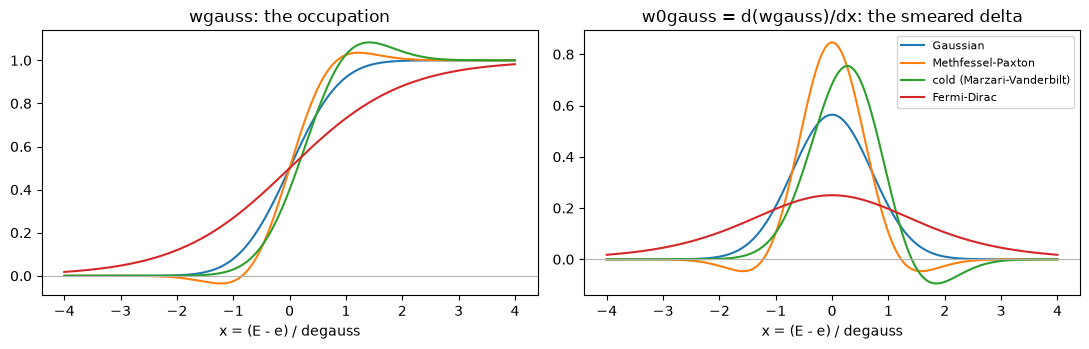

In [3]:
x = np.linspace(-4, 4, 801)
names = {0: "Gaussian", 1: "Methfessel-Paxton",
         -1: "cold (Marzari-Vanderbilt)", -99: "Fermi-Dirac"}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ngauss, label in names.items():
    axes[0].plot(x, wgauss(x, ngauss), label=label)
    axes[1].plot(x, w0gauss(x, ngauss), label=label)
axes[0].set_title("wgauss: the occupation")
axes[1].set_title("w0gauss = d(wgauss)/dx: the smeared delta")
for ax in axes:
    ax.set_xlabel("x = (E - e) / degauss")
    ax.axhline(0.0, color="0.7", lw=0.8)
axes[1].legend(fontsize=8)
fig.tight_layout()

# Each one is normalised: a delta function integrates to 1, however it is shaped.
wide = np.linspace(-40, 40, 400001)
for ngauss, label in names.items():
    area = np.trapezoid(np.asarray(w0gauss(wide, ngauss)), wide)
    print(f"{label:26s} integral = {area:.10f}")

## 3. Only N(E) is written down

`tetra.f90` codes the tetrahedron DOS twice: `dosint`, the integrated density of states,
and `dost`, the density of states itself --- four branches each, a piecewise cubic and its
piecewise quadratic derivative, written out side by side. They are exact derivatives of
one another. For example on `e3 <= E < e4`,

    d/dE [ 1 - (e4-E)^3 / ((e4-e1)(e4-e2)(e4-e3)) ]  =  3 (e4-E)^2 / ((e4-e1)(e4-e2)(e4-e3))

which is QE's `dost` expression line for line.

So only `dosint` is transcribed here and `D(E)` is `jax.grad` of it --- the same trade
`xc/functional.py` makes, where only the exchange-correlation *energy* is written down and
the potential comes from `jax.grad`. Half the transcription, half the surface for a sign
slip, and the sum rule `integral D dE = N` becomes an identity rather than a test.

The smearing scheme is written the same way:
`N(E) = sum_k w_k sum_n wgauss((E - e_nk)/degauss)`, and `D(E)` is its derivative, which
recovers `dos_g`'s expression exactly.

In [4]:
dos_tetra, _ = run_dos(si, si_pseudos, si_scf.density, grid=grid, nbnd=8, scheme="tetrahedra")
dos_gauss, _ = run_dos(si, si_pseudos, si_scf.density, grid=grid, nbnd=8,
                       scheme="gaussian", degauss=0.02)

step = dos_tetra.energies[1] - dos_tetra.energies[0]
trapezoid = np.concatenate(
    [[0.0], np.cumsum((dos_tetra.dos[1:] + dos_tetra.dos[:-1]) / 2) * step]
)
print(f"max |trapezoid of D  -  N|  = {np.abs(trapezoid - dos_tetra.integrated).max():.2e} states")
print(f"N at the valence-band top   = {dos_tetra.states_below(valence_top):.10f}")
print(f"N above the highest band    = {dos_tetra.integrated[-1]:.10f}   (8 bands x 2)")

max |trapezoid of D  -  N|  = 5.09e-04 states
N at the valence-band top   = 7.9999999511
N above the highest band    = 15.9999999995   (8 bands x 2)


That first number is the trapezoid rule's own error, not a discrepancy: `N` is exact at
every grid point by construction. The second is the point of the whole exercise --- eight
valence electrons to eight decimal places, out of an integration scheme that was never
told how many electrons there are.

## 4. Silicon: the gap is the difference between the two schemes

Here is what the two schemes actually give. Away from the band edges they agree; in the
gap they do not, and cannot.

D at mid-gap, tetrahedra = 0.000e+00 states/eV
D at mid-gap, Gaussian   = 2.732e-02 states/eV


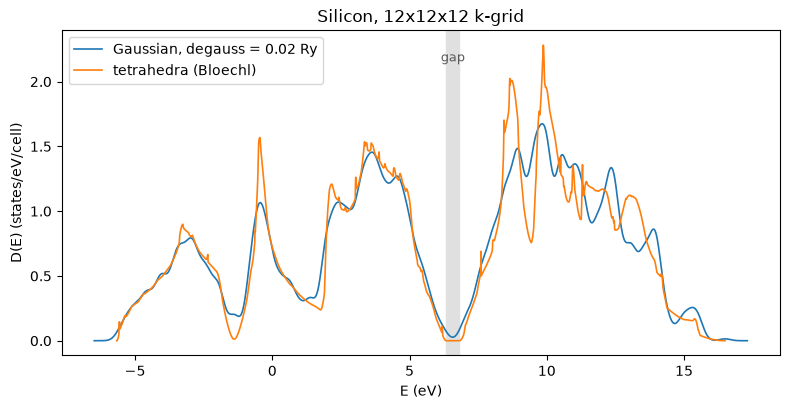

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(dos_gauss.energies_ev, dos_gauss.dos_ev, label="Gaussian, degauss = 0.02 Ry", lw=1.2)
ax.plot(dos_tetra.energies_ev, dos_tetra.dos_ev, label="tetrahedra (Bloechl)", lw=1.2)
ax.axvspan(valence_top * RY_TO_EV, conduction_bottom * RY_TO_EV, color="0.88", zorder=0)
ax.text(0.5 * (valence_top + conduction_bottom) * RY_TO_EV, 0.9 * ax.get_ylim()[1],
        "gap", ha="center", fontsize=9, color="0.35")
ax.set_xlabel("E (eV)")
ax.set_ylabel("D(E) (states/eV/cell)")
ax.set_title(f"Silicon, {grid[0]}x{grid[1]}x{grid[2]} k-grid")
ax.legend()
fig.tight_layout()

middle = 0.5 * (valence_top + conduction_bottom)
print(f"D at mid-gap, tetrahedra = {dos_tetra.at(middle) / RY_TO_EV:.3e} states/eV")
print(f"D at mid-gap, Gaussian   = {dos_gauss.at(middle) / RY_TO_EV:.3e} states/eV")

The Gaussian puts states in the middle of a gap that has none. That is not a small error
to be tolerated: it is the reason the tetrahedron method exists. A smearing wide enough to
give a smooth DOS on an affordable k-grid is wide enough to close a semiconductor gap, and
no choice of `degauss` escapes the trade --- narrower, and the DOS becomes a comb of the
individual k-points.

## 5. Convergence with the k-grid

The tetrahedron method's error falls as the grid is refined; the smearing's error has a
floor set by `degauss` that no number of k-points removes.

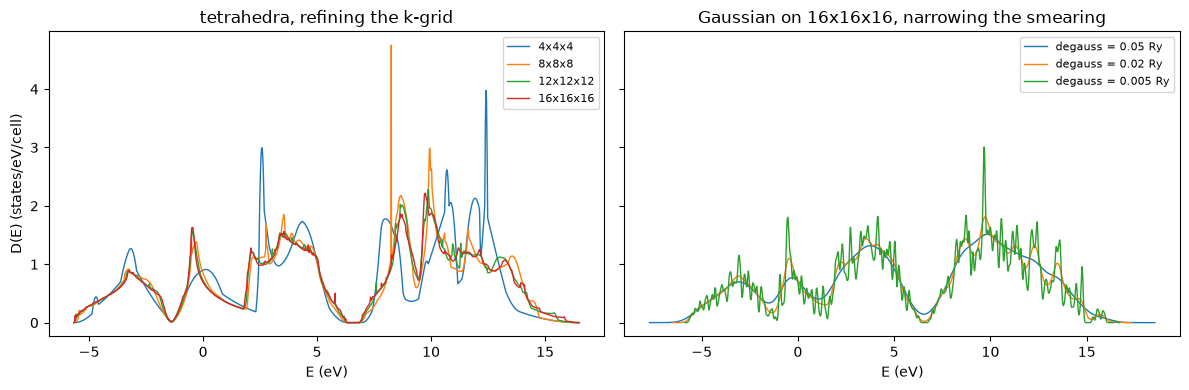

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.0), sharey=True)
for n in (4, 8, 12, 16):
    d, _ = run_dos(si, si_pseudos, si_scf.density, grid=(n, n, n), nbnd=8, scheme="tetrahedra")
    axes[0].plot(d.energies_ev, d.dos_ev, lw=1.0, label=f"{n}x{n}x{n}")
for degauss in (0.05, 0.02, 0.005):
    d, _ = run_dos(si, si_pseudos, si_scf.density, grid=(16, 16, 16), nbnd=8,
                   scheme="gaussian", degauss=degauss)
    axes[1].plot(d.energies_ev, d.dos_ev, lw=1.0, label=f"degauss = {degauss} Ry")
axes[0].set_title("tetrahedra, refining the k-grid")
axes[1].set_title("Gaussian on 16x16x16, narrowing the smearing")
for ax in axes:
    ax.set_xlabel("E (eV)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("D(E) (states/eV/cell)")
fig.tight_layout()

On the right, the widest smearing washes out the structure entirely and the narrowest
starts to show the k-points themselves. On the left there is no such dial: the answer
simply converges.

## 6. Aluminium, and the three variants against Quantum ESPRESSO

Silicon has a gap, so its Fermi level is not a number the tetrahedra have to find. A metal
is where the method earns its keep, and it is what QE's own benchmarks test: three inputs
in `test-suite/pw_metal/`, one per variant, on fcc aluminium.

The mapping from the `occupations` keyword to the algorithm is `set_occupations.f90`'s and
is worth reading rather than guessing:

| `occupations` | `tetra_type` | algorithm |
|---|---|---|
| `tetrahedra` | 0 | Bloechl, with his `O(1/N^2)` curvature correction |
| `tetrahedra-lin` | 1 | plain linear tetrahedra |
| `tetrahedra-opt` | 2 | Kawamura's optimised tetrahedra: the corner energies are a 20-point stencil |

The two families do not even cut a microcell into the same six tetrahedra ---
`tetra_init` hardwires one decomposition, `opt_tetra_init` picks the shortest of the four
body diagonals as its shaft --- which is why the three give visibly different Fermi levels
from the same eigenvalues.

In [7]:
al, al_pseudos = load(QE / "pw_metal" / "metal-tetrahedra.in")
al_scf = run_scf(al, al_pseudos, conv_thr=1e-10)
al_ref = read_qe_output(QE / "pw_metal" / "benchmark.out.git.inp=metal-tetrahedra.in")

print(f"occupations = {al.occupations!r},  {al.kpoints.nk} irreducible k-points")
print(f"{'':24s}{'pypresso':>16s}{'Quantum ESPRESSO':>20s}{'difference':>14s}")
print(f"{'total energy (Ry)':24s}{al_scf.total_energy:16.8f}{al_ref.total_energy:20.8f}"
      f"{al_scf.total_energy - al_ref.total_energy:14.2e}")
print(f"{'Fermi energy (eV)':24s}{al_scf.fermi_energy * RY_TO_EV:16.4f}"
      f"{al_ref.fermi_energy:20.4f}"
      f"{al_scf.fermi_energy * RY_TO_EV - al_ref.fermi_energy:14.2e}")
for term, value in al_ref.energy_terms.items():
    print(f"  {term:22s}{al_scf.energy_terms[term]:16.8f}{value:20.8f}"
          f"{al_scf.energy_terms[term] - value:14.2e}")

occupations = 'tetrahedra-opt',  10 irreducible k-points
                                pypresso    Quantum ESPRESSO    difference
total energy (Ry)            -4.16607791         -4.16607788     -2.55e-08
Fermi energy (eV)                 8.1535              8.1533      2.36e-04
  one-electron                2.96053570          2.96053529      4.07e-07
  hartree                     0.00998167          0.00998611     -4.44e-06
  xc                         -1.63476074         -1.63476476      4.02e-06
  ewald                      -5.50183453         -5.50183453     -1.86e-09


There is no `smearing contrib. (-TS)` line in that table, and its absence is the point:
the tetrahedron method integrates the true step function, so there is no entropy term and
the energy is not a free energy. QE prints four terms for these runs where it prints five
for a smeared metal.

The other two benchmarks are `calculation='nscf'` runs on a 6x6x6 grid, seeded --- QE's
`jobconfig` runs them in sequence in one directory --- by exactly the density above. Only
the Fermi level is printed for them, and that is the right thing to compare: it is the one
number that depends on the whole machinery at once, the decomposition, the map from the
full grid into the irreducible wedge, and the integrated DOS.

In [8]:
print(f"{'input':26s}{'occupations':18s}{'pypresso E_F':>14s}{'QE E_F':>10s}{'diff (meV)':>12s}")
for name in ("metal-tetrahedra-1.in", "metal-tetrahedra-2.in"):
    system, _ = load(QE / "pw_metal" / name)
    result = run_nscf(system, al_pseudos, al_scf.density, nbnd=4)
    reference = read_qe_output(QE / "pw_metal" / f"benchmark.out.git.inp={name}")
    ours = result.fermi_energy * RY_TO_EV
    print(f"{name:26s}{system.occupations:18s}{ours:14.4f}{reference.fermi_energy:10.4f}"
          f"{1000 * (ours - reference.fermi_energy):12.2f}")

input                     occupations         pypresso E_F    QE E_F  diff (meV)


metal-tetrahedra-1.in     tetrahedra                8.3056    8.3056       -0.00


metal-tetrahedra-2.in     tetrahedra-lin            8.2622    8.2622       -0.01


Three variants, three different numbers, each one reproduced. Nothing in the code branches
on which benchmark is being run, so agreeing with all three at once is a much stronger
statement than agreeing with any one of them.

Aluminium's density of states is also the textbook nearly-free-electron one: `D(E)` grows
as the square root of the energy above the band bottom, because the volume of the Fermi
sphere grows as `E^(3/2)`. That is a shape known independently of any code.

states below E_F  = 3.000003   (3 valence electrons)
D(E_F)            = 0.3751 states/eV/cell


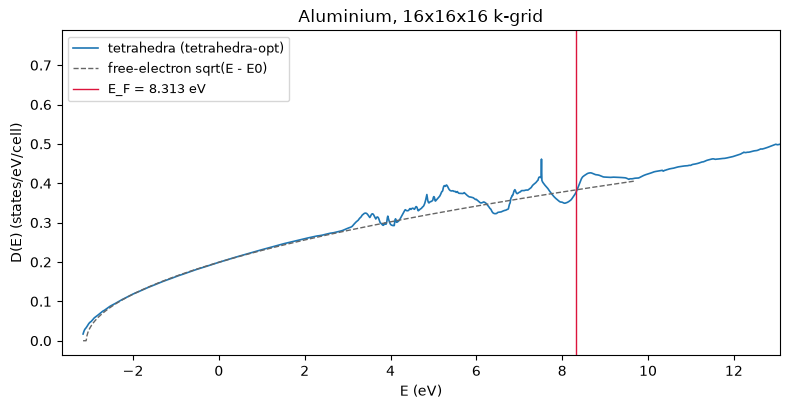

In [9]:
al_dos, al_nscf = run_dos(al, al_pseudos, al_scf.density, grid=(16, 16, 16), nbnd=6)
ef = al_dos.fermi_energy
bottom = al_nscf.eigenvalues.min()

window = (al_dos.energies > bottom + 0.03) & (al_dos.energies < bottom + 0.30)
slope, intercept = np.polyfit(al_dos.energies[window], al_dos.dos[window] ** 2, 1)
sqrt_law = np.sqrt(np.maximum(slope * al_dos.energies + intercept, 0.0))
shown = al_dos.energies < ef + 0.1

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(al_dos.energies_ev, al_dos.dos_ev, lw=1.2, label=f"tetrahedra ({al_dos.scheme})")
ax.plot(al_dos.energies_ev[shown], (sqrt_law / RY_TO_EV)[shown], "--", lw=1.0,
        color="0.4", label="free-electron sqrt(E - E0)")
ax.axvline(ef * RY_TO_EV, color="crimson", lw=1.0, label=f"E_F = {ef * RY_TO_EV:.3f} eV")
ax.set_xlim(bottom * RY_TO_EV - 0.5, (ef + 0.35) * RY_TO_EV)
ax.set_xlabel("E (eV)")
ax.set_ylabel("D(E) (states/eV/cell)")
ax.set_title("Aluminium, 16x16x16 k-grid")
ax.legend(fontsize=9)
fig.tight_layout()

print(f"states below E_F  = {al_dos.states_below(ef):.6f}   (3 valence electrons)")
print(f"D(E_F)            = {al_dos.at(ef) / RY_TO_EV:.4f} states/eV/cell")

The square root holds until the second band comes in and the zone boundary starts putting
van Hove kinks in the curve. `N(E_F) = 3` closes the loop: the Fermi level was found by
bisecting the tetrahedron count during the NSCF run, and the DOS was built afterwards on
an independent energy grid, so recovering the electron count from it is a check that the
two paths through the same `N(E)` agree.

## 7. The NaN that only appears in the gradient

`tetra_dos_t` is an `IF/ELSEIF` chain over five cases, and QE only ever evaluates the
selected one. JAX cannot do that: the branch condition depends on traced values, so every
branch is computed and `jnp.where` picks between them. Which is fine for the value --- and
not fine for the derivative.

Degenerate corner energies are routine (any high-symmetry point, any flat band). When
`e1 == e2`, the branch for `e1 <= E < e2` is *empty*, so QE never evaluates it --- but here
it is evaluated anyway, and its denominator `(e2-e1)(e3-e1)(e4-e1)` is zero. The forward
value survives, because `where` throws the result away. The gradient does not: `where`
hands the dead branch a zero cotangent, and `0 * inf` is `NaN`.

The fix is to clamp the denominator **before** dividing rather than masking the quotient
afterwards, which is exact because the clamp can never fire on a live branch. Here is the
difference, on a deliberately flat band.

In [10]:
import jax
import jax.numpy as jnp

from pypresso.scf.tetrahedra import build_tetrahedra, integrated_states, _sorted_corners

tetra = build_tetrahedra("bloechl", (3, 3, 3), (0, 0, 0),
                         np.eye(3, dtype=int)[None], np.eye(3), time_reversal=False)
flat = jnp.zeros((int(np.asarray(tetra.corners).max()) + 1, 1))  # every corner energy equal


def naive_fraction(e, energy):
    # The same cubic, but dividing without clamping the denominator first.
    e1, e2, e3, e4 = (e[..., i] for i in range(4))
    first = (energy - e1) ** 3 / ((e2 - e1) * (e3 - e1) * (e4 - e1))
    return jnp.where(energy >= e4, 1.0, jnp.where(energy < e1, 0.0, first))


def naive(energy):
    e_sorted, _ = _sorted_corners(tetra, flat)
    return 2.0 / tetra.ntetra * jnp.sum(naive_fraction(e_sorted, energy))


def guarded(energy):
    e_sorted, _ = _sorted_corners(tetra, flat)
    return integrated_states(e_sorted, energy, tetra.ntetra, 2.0)


for energy in (-0.5, 0.5):
    print(f"E = {energy:+.1f}    naive  N = {float(naive(energy)):6.3f}   "
          f"dN/dE = {float(jax.grad(naive)(energy)):8.3f}")
    print(f"           guarded  N = {float(guarded(energy)):6.3f}   "
          f"dN/dE = {float(jax.grad(guarded)(energy)):8.3f}")

E = -0.5    naive  N =  0.000   dN/dE =      nan


           guarded  N =  0.000   dN/dE =    0.000
E = +0.5    naive  N =  2.000   dN/dE =      nan
           guarded  N =  2.000   dN/dE =    0.000


The naive version's *value* is right in both cases and its *gradient* is `NaN`. That is
the failure mode to watch for whenever a Fortran branch chain is turned into
evaluate-everything-and-select, and it is not specific to tetrahedra --- the same pattern
appears anywhere a piecewise formula has removable singularities in its dead branches.

It matters here rather than being a curiosity because `D(E)` *is* a gradient, and because
a differentiable DOS makes the Fermi level differentiable too: `N(E_F) = nelec` gives
`dE_F/dx = -(dN/dx) / D(E_F)` by implicit differentiation, with the density of states
itself in the denominator.

## 8. The output file

`dos.x` writes a three-column text file, and `io/output.py` writes the same one --- down to
Fortran's exponent convention, where the mantissa is normalised into `[0.1, 1)` so that
`0.1234E+01` is what Python would print as `1.2340E+00`. That is so a file written here can
be diffed against one written by `dos.x`, not merely plotted beside it.

From the command line the whole sequence is one invocation:

```
python3 -m pypresso.cli dos metal-tetrahedra.in --pseudo-dir tests/data/pseudo --kgrid 12 12 12
```

In [11]:
print(format_dos(al_dos)[:420])

#  E (eV)   dos(E)     Int dos(E) EFermi =    8.313 eV
  -3.163  0.1703E-01  0.3335E-03
  -3.153  0.2066E-01  0.5222E-03
  -3.143  0.2390E-01  0.7454E-03
  -3.133  0.2673E-01  0.9988E-03
  -3.123  0.2881E-01  0.1278E-02
  -3.113  0.3003E-01  0.1572E-02
  -3.103  0.3136E-01  0.1879E-02
  -3.093  0.3280E-01  0.2200E-02
  -3.083  0.3433E-01  0.2535E-02
  -3.073  0.3596E-01  0.2887E-02
  -3.063  0.3769E-01  0.3255E-02
  


## What this phase established

* Both Brillouin-zone integration schemes, behind a name registry: four smearings and
  three tetrahedron variants, selectable by the names a `pw.x` or `dos.x` input uses.
* Tetrahedron **occupations** inside the SCF, matching all three of QE's aluminium
  benchmarks --- the total energy to 2.5e-8 Ry and the Fermi levels to the four decimals
  QE prints.
* An NSCF grid run lifted out of the band-structure workflow, so a DOS is
  SCF -> NSCF -> integrate rather than a special case.
* `w0gauss` as `jax.jvp` of `wgauss`, and `D(E)` as `jax.grad` of `N(E)`: two places where
  the derivative is taken rather than transcribed, and where the sum rules then follow by
  construction rather than by luck.

Still to come for the density of states: the projected DOS (`projwfc.x`), which needs the
atomic-orbital projections and not only the eigenvalues, and spin, which adds a channel
index to everything above.